<a href="https://colab.research.google.com/github/fzunigaGH/Proyectos/blob/main/Clasificaci%C3%B3n_de_im%C3%A1genes_con_redes_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fzunigaGH/Proyectos/blob/main/TU_ARCHIVO.ipynb)

#Identificación de escenarios naturales del mundo

## El Problema

Para un conjunto de imágenes que corresponden a escenarios naturales del mundo, con seis diferentes clases:
* buildings: Para escenarios con edificios
* forest: Escenarios de bosques
* glacier: Glaciares
* mountain: Escenarios con montañas
* sea: Imágenes con mar
* street: Escenarios de ciudad

La base de datos se encuentra en cinco archivos serializados (pickle):
* cnn_train_X.npy: imágenes destinadas para entrenar los modelos
* cnn_train_y.npy: etiquetas asociadas a las imágenes de entrenamiento
* cnn_test_X.npy: imágenes para test
* cnn_test_y.npy: etiquetas correspondiente a las imágenes de test
* cnn_pred_X.npy conjunto de imágenes sin etiquetar destinadas a predicción.

## Objetivo

Generar una red neuronal convolucional que permita clasificar imágenes correspondientes a los escenarios considerados anteriormente.

1. En primera instancia se procederá a importar las libreriías necearias para aplicar el preprocesamiento de datos, visualización y creación de un modelo de red nuronal feedforward
2. A continuación se descartarán las columnas **index**, **arrival_date_year**, **agent**, **country**, **company**, **reservation_status** y **reservation_status_date** y se verificará la presencia de datos ausentes (NaN). En caso que existan, estos registros serán eliminados siempre y cuando la cantidad sea menor al 4% del total. En caso que sea superior, se decidirá en función de cada uno ellos, si se prescinde de la característica o si se imputan los datos faltantes describiendo y aplicando alguna estrategía para tales fines.
3. Se realizará un análisis descriptivo y prepara los datos. Para esto:

    **a.** Se Seleccionarán 5 variables que que sean considas relevantes (que no sean la variable **adr**) con respecto a cancelar una reserva.
    
    **b.** Se construirá un histograma para la variable adr con reservas canceladas y no canceladas, comentando el resultado obtenido.
    
    **c.** Se verificará la presencia de outlier para la variable adr. En caso que presente valores extremos se indicará la cantidad de outliers por arriba, y la cantidad deoutlier por abajo. **Sólo se eliminarán los tres valores más extremos en ambos casos**, los demás serán reemplazados por el valor promedio de la variable.

    **d.** Las variables categóricas serán transformadas a variables dummies, estandarizando las variables independientes con media igual a cero y desviación estándar 1.
    
    **e.** El Dataset resultante de las actividades detalladas anteriormente, procederá a ser dividido en set de entrenamiento y test, para este último se considerará el 33% de registros.

4. Se implementarán 2 modelos de Redes Neuronales considerando las siguientes características:

    a. Cada modelo debe contar con tres capas ocultas.
    
    b. El primer modelo debe tener funciones de activación tanh, relu y tanh en las capas ocultas, mientras que el segundo sólo funciones tanh en sus capas
    ocultas.
    
    c. Cada modelo debe tener un mínimo de 20 neuronas para cada capa oculta.  Use un optimizador SGD, con 10 épocas de entrenamiento; cada capa deberá    tener una neurona de sesgo. Debes decidir cómo se inicializan los pesos y el
    sesgo en cada capa oculta y de salida.

Los resultados obtenidos serán mostrados en un gráfico que tendrá una curva de accuracy para cada modelo en cada época de entrenamiento. Se espera que cada modelo debe lograr un accuracy superior al 75%. Se expondrán las conclusiones al respecto.

5. A continuación se procederá a construir una red neuronal con regularización Dropout aplicando búsqueda de grilla para tres fold. El modelo debe conseguir un accuracy superior al 80%. La búsqueda debe sintonizar los siguientes hiper parámetros:
    
    a. Cantidad de capas ocultas: de 3 o 4

    b. Método de optimización: Adam o SGD

    c. learning_rate: 0.03 y 0.06
    
    d. Cantidad de neuronas en las capas ocultas: 20
    
    e. Funciones de activación en las capas ocultas: tanh
    
    f. Rate para Dropout: 0.001
    g. Inicialización de los pesos: [glorot_normal, glorot_uniform]

Se presentarán los hiper parámetros óptimos encontrados por la búsqueda de grilla.

Se Calcularán las métricas asociadas a la matriz de confusión al aplicar el
modelo con los hiper parámetros óptimos al conjunto de test y se representará la curva ROC para el mejor modelo incluyendo el AUC.

6. Del conjunto original (sin los valores excluidos) se escogerán al azar cinco observaciones en que “deposit_type_Non Refund” sea cero, y con esto realiza una predicción usando el mejor modelo encontrado por la búsqueda de grilla anterior. Los resultados obtenidos serán comentados.

## Librerías, Funciones

### Librerías

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.optimizers import SGD


In [ ]:
from tensorflow.keras.constraints import MaxNorm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report

### Funciones

In [ ]:
def show_images(X_img, y_img, total_images, nrow=2, ncol=4, seed=None):
    fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=(4 + ncol, 4 + nrow / 2.5),
                           sharex=True, sharey=True)

    if seed is not None:
        np.random.seed(seed)

    idxs = np.random.choice(len(X_img), total_images, replace=False)

    for i in range(nrow):
        for j in range(ncol):
            idx = idxs[i * ncol + j]
            ax[i, j].imshow(X_img[idx])
            ax[i, j].set_title(y_img[idx])
            ax[i, j].axis('off')

    plt.tight_layout()
    plt.show()

##1. Importa correctamente los conjuntos de datos, desplegando la cantidad de registros de cada categoría para cada conjunto. Despliega ocho imágenes aleatorias del conjunto de entrenamiento y codifica las etiquetas con OneHotEncoder para los conjuntos de entrenamiento y Test.

###1.2.-Importa correctamente los conjuntos de datos, desplegando la cantidad de registros de cada categoría para cada conjunto

In [ ]:
X_train = np.load('/content/drive/MyDrive/Colab Notebooks/06 - Modelos Avanzados/06 - Procesamiento y redes recurrentes (parte I)/DataSet/cnn_train_X.npy', allow_pickle=True)
y_train = np.load('/content/drive/MyDrive/Colab Notebooks/06 - Modelos Avanzados/06 - Procesamiento y redes recurrentes (parte I)/DataSet/cnn_train_y.npy', allow_pickle=True)
X_test = np.load('/content/drive/MyDrive/Colab Notebooks/06 - Modelos Avanzados/06 - Procesamiento y redes recurrentes (parte I)/DataSet/cnn_test_X.npy', allow_pickle=True)
y_test = np.load('/content/drive/MyDrive/Colab Notebooks/06 - Modelos Avanzados/06 - Procesamiento y redes recurrentes (parte I)/DataSet/cnn_test_y.npy', allow_pickle=True)
X_pred = np.load('/content/drive/MyDrive/Colab Notebooks/06 - Modelos Avanzados/06 - Procesamiento y redes recurrentes (parte I)/DataSet/cnn_pred_X.npy', allow_pickle=True)


In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_pred.shape


((14034, 32, 32, 3), (14034,), (3000, 32, 32, 3), (3000,), (7301, 32, 32, 3))

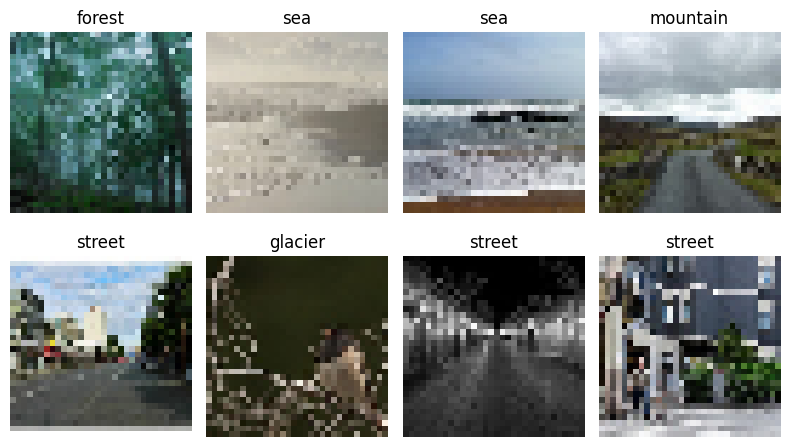

In [ ]:
'''En caso de querer que las imagenes mostradas sean aleatorias,
 se logra suprimiendo el parametro seed =42'''
show_images(X_train, y_train, 8, seed = 42)

In [ ]:
pd.Series(y_train).value_counts()

,count
mountain,2512
glacier,2404
street,2382
sea,2274
forest,2271
buildings,2191


In [ ]:
y_train

array(['forest', 'forest', 'forest', ..., 'sea', 'sea', 'sea'],
      dtype=object)

In [ ]:
y_train.shape[0]

14034

In [ ]:
X_pred.shape[0]

7301

In [ ]:
y_test.shape[0]

3000

In [ ]:
pd.Series(y_test).value_counts()

,count
glacier,553
mountain,525
sea,510
street,501
forest,474
buildings,437


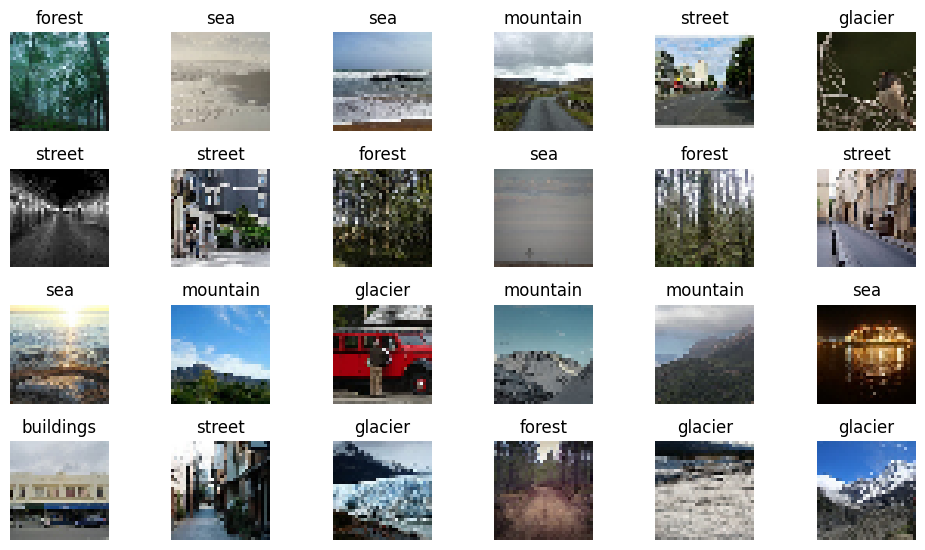

In [ ]:
show_images(X_train, y_train, len(X_train) ,nrow=4, ncol=6, seed = 42)

###1.3.- Codificación de las etiquetas con OneHotEncoder para los conjuntos de entrenamiento y Test.

In [ ]:
one_hot = OneHotEncoder()

In [ ]:
y_train.shape[0]

14034

In [ ]:
y_train.reshape(-1,1)

array([['forest'],
       ['forest'],
       ['forest'],
       ...,
       ['sea'],
       ['sea'],
       ['sea']], dtype=object)

In [ ]:
one_hot.fit_transform(y_train.reshape(-1,1))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14034 stored elements and shape (14034, 6)>

In [ ]:
y_train = one_hot.fit_transform(y_train.reshape(-1, 1)).toarray() # .toarray() para pasar de sparce matrix a ndarray
y_test = one_hot.fit_transform(y_test.reshape(-1, 1)).toarray()

In [ ]:
y_train.shape

(14034, 6)

In [ ]:
y_train

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.]])

In [ ]:
y_test.shape

(3000, 6)

In [ ]:
y_train

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.]])

##2. Implementa una red neuronal multicapa Fully Connected para clasificar las imágenes, las que deben contener un mínimo de cinco capas ocultas. Despliega las métricas (aplicadas al conjunto de test) que estimes conveniente para medir el rendimiento del modelo.

In [ ]:
X_train.shape

(14034, 32, 32, 3)

### 2.1 Red neuronal multicapa para clasificar las imágenes

In [ ]:
n_class = 6

fcnn = Sequential()

fcnn.add(tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3]))) # ancho imagen, alto imagen, N° canales
fcnn.add(Flatten())

fcnn.add(Dense(units = 1024, activation = "relu", use_bias = True, kernel_initializer = "he_normal"))


fcnn.add(Dense(units = 512, activation = "relu", use_bias = True, kernel_initializer = "he_normal"))


fcnn.add(Dense(units = 256, activation = "relu", use_bias = True, kernel_initializer = "he_normal"))


fcnn.add(Dense(units = 128, activation = "relu", use_bias = True, kernel_initializer = "he_normal"))


fcnn.add(Dense(units = 64, activation = "relu", use_bias = True, kernel_initializer = "he_normal" ))

fcnn.add(Dense(units = n_class, activation = "softmax", use_bias = True, kernel_initializer = "he_normal"))


In [ ]:
fcnn.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])
fcnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,422 (14.67 MB)

 Trainable params: 3,844,422 (14.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 20
fcnn.fit(X_train, y_train, batch_size=10, epochs=epochs, validation_data=(X_test, y_test))
score = fcnn.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {score[1]}')

Epoch 1/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4357 - loss: 1.4338 - val_accuracy: 0.4747 - val_loss: 1.3821
Epoch 2/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5316 - loss: 1.2283 - val_accuracy: 0.4860 - val_loss: 1.3066
Epoch 3/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5517 - loss: 1.1615 - val_accuracy: 0.5517 - val_loss: 1.1666
Epoch 4/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5682 - loss: 1.1238 - val_accuracy: 0.5557 - val_loss: 1.2022
Epoch 5/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5904 - loss: 1.0859 - val_accuracy: 0.5497 - val_loss: 1.1720
Epoch 6/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5924 - loss: 1.0634 - val_accuracy: 0.5663 - val_loss: 1.1230
Epoch 7/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6030 - loss: 1.0341 - val_accuracy: 0.5610 - val_loss: 1.1540
Epoch 8/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6125 - loss: 1.0120 

In [ ]:
y_pred = fcnn.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
decoded_y_test = y_test.argmax(axis=1)
decoded_y_pred = y_pred.argmax(axis=1)

In [ ]:
print(classification_report(decoded_y_test, decoded_y_pred))

              precision    recall  f1-score   support

           0       0.51      0.41      0.45       437
           1       0.74      0.77      0.75       474
           2       0.64      0.58      0.61       553
           3       0.58      0.66      0.62       525
           4       0.45      0.51      0.48       510
           5       0.68      0.66      0.67       501

    accuracy                           0.60      3000
   macro avg       0.60      0.60      0.60      3000
weighted avg       0.60      0.60      0.60      3000



##3. Desarrolla una red neuronal Convolucional usando tres o más capas convolucionales y dos o más capas densas, de manera que la cantidad de parámetros a estimar se encuentre en el intervalo [3MM, 8MM], con 25 épocas. Muestra la curva de la pérdida para cada época y la curva de la métrica accuracy (conjunto test).

###3.1.- modelo Red Neuronal Convolucional (CNN1)

In [ ]:
n_class = 6
cnn1 = Sequential()
cnn1.add(tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3])))


cnn1.add(Conv2D(filters=16, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', use_bias=True, kernel_constraint=MaxNorm(3), kernel_initializer='glorot_normal'))
cnn1.add(Conv2D(filters=16, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', use_bias=True, kernel_constraint=MaxNorm(3), kernel_initializer='glorot_normal'))
cnn1.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))

cnn1.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', use_bias=True, kernel_constraint=MaxNorm(3), kernel_initializer='glorot_normal'))
cnn1.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', use_bias=True, kernel_constraint=MaxNorm(3), kernel_initializer='glorot_normal'))
cnn1.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', use_bias=True, kernel_constraint=MaxNorm(3), kernel_initializer='glorot_normal'))
cnn1.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))

cnn1.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', use_bias=True, kernel_constraint=MaxNorm(3), kernel_initializer='glorot_normal'))
cnn1.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', use_bias=True, kernel_constraint=MaxNorm(3), kernel_initializer='glorot_normal'))
cnn1.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))

cnn1.add(Flatten())

cnn1.add(Dense(units=128, activation='relu', use_bias=True, kernel_constraint=MaxNorm(3), kernel_initializer='glorot_normal'))
cnn1.add(Dense(units=128, activation='relu', use_bias=True, kernel_constraint=MaxNorm(3), kernel_initializer='glorot_normal'))

cnn1.add(Dense(units=n_class, activation='softmax', use_bias=True, kernel_initializer='glorot_normal'))

cnn1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn1.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 31, 31, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 31, 31, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 31, 31, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 53824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │     6,889,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,988,214 (26.66 MB)

 Trainable params: 6,988,214 (26.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 20
cnn1_history = cnn1.fit(X_train, y_train, batch_size=10, epochs=epochs, validation_data=(X_test, y_test))
score = cnn1.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {score[1]}')

Epoch 1/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.5650 - loss: 1.0848 - val_accuracy: 0.6270 - val_loss: 0.9519
Epoch 2/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6571 - loss: 0.8812 - val_accuracy: 0.6867 - val_loss: 0.8444
Epoch 3/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7009 - loss: 0.7919 - val_accuracy: 0.7137 - val_loss: 0.7725
Epoch 4/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7264 - loss: 0.7401 - val_accuracy: 0.7477 - val_loss: 0.6799
Epoch 5/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7406 - loss: 0.6987 - val_accuracy: 0.7343 - val_loss: 0.7407
Epoch 6/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7552 - loss: 0.6695 - val_accuracy: 0.7670 - val_loss: 0.6732
Epoch 7/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7641 - loss: 0.6328 - val_accuracy: 0.7590 - val_loss: 0.6535
Epoch 8/20
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7738 - loss: 

In [ ]:
y_pred_cnn1 = cnn1.predict(X_test)
decoded_y_pred_cnn1 = y_pred_cnn1.argmax(axis=1)
print('\nReporte de clasificación para el modelo CNN1:')
print(classification_report(decoded_y_test, decoded_y_pred_cnn1))

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

Reporte de clasificación para el modelo CNN1:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       437
           1       0.97      0.82      0.89       474
           2       0.75      0.77      0.76       553
           3       0.89      0.59      0.71       525
           4       0.66      0.91      0.77       510
           5       0.74      0.81      0.77       501

    accuracy                           0.77      3000
   macro avg       0.79      0.77      0.77      3000
weighted avg       0.79      0.77      0.77      3000



###3.2.- Curvas de pérdida y precisión para el modelo CNN mejorado

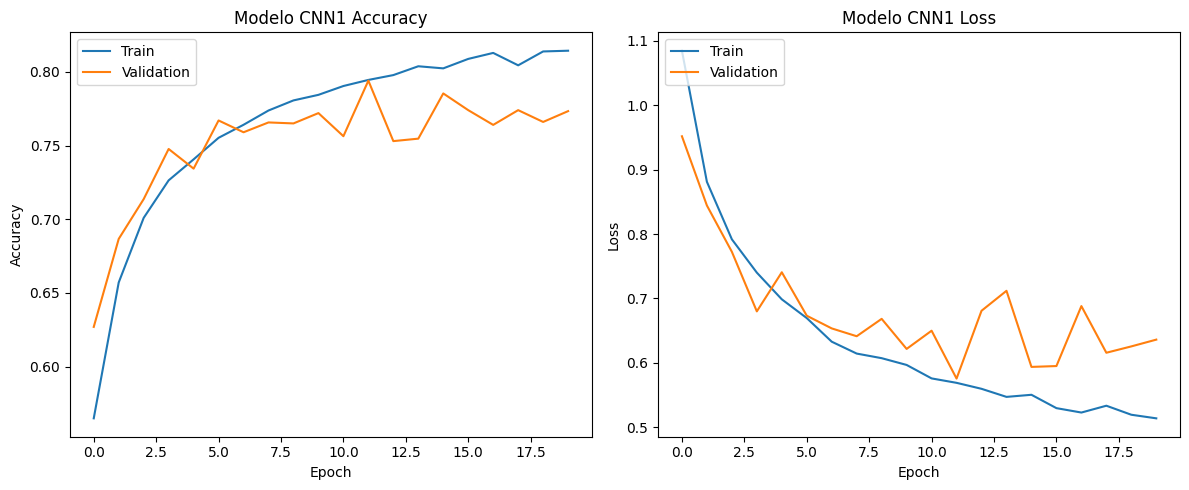

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(cnn1_history.history['accuracy'])
plt.plot(cnn1_history.history['val_accuracy'])
plt.title('Modelo CNN1 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(cnn1_history.history['loss'])
plt.plot(cnn1_history.history['val_loss'])
plt.title('Modelo CNN1 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

##4. Implementa una red neuronal Convolucional que mejore la capacidad de generalización alcanzada en el modelo anterior. Para esto usa 16 o más capas (entre convolucionales y densas) y mide su rendimiento.

### 4.1 Red neuronal convolucional mejorada

In [ ]:
n_class = 6
cnn2 = Sequential()

# Input Layer
cnn2.add(tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3])))

# Block 1 (2 Conv2D layers)
cnn2.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
cnn2.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
cnn2.add(MaxPooling2D(pool_size=(2, 2)))
cnn2.add(Dropout(0.15)) # Reduced dropout

# Block 2 (2 Conv2D layers)
cnn2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
cnn2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
cnn2.add(MaxPooling2D(pool_size=(2, 2)))
cnn2.add(Dropout(0.15)) # Reduced dropout

# Block 3 (3 Conv2D layers)
cnn2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
cnn2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
cnn2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal')) # Added layer
cnn2.add(MaxPooling2D(pool_size=(2, 2)))
cnn2.add(Dropout(0.15)) # Reduced dropout

# Block 4 (3 Conv2D layers)
cnn2.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
cnn2.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
cnn2.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
cnn2.add(MaxPooling2D(pool_size=(2, 2)))
cnn2.add(Dropout(0.15)) # Reduced dropout

# Flattening (output will be 2*2*256 = 1024 units)
cnn2.add(Flatten())

# Dense layers (6 Dense layers in total, including output)
cnn2.add(Dense(units=480, activation='relu', kernel_initializer='he_normal'))  # Adjusted units to reduce parameters
cnn2.add(Dropout(0.3)) # Reduced dropout
cnn2.add(Dense(units=192, activation='relu', kernel_initializer='he_normal'))  # Adjusted units to reduce parameters
cnn2.add(Dropout(0.3)) # Reduced dropout
cnn2.add(Dense(units=96, activation='relu', kernel_initializer='he_normal'))  # Adjusted units to reduce parameters
cnn2.add(Dropout(0.3)) # Reduced dropout
cnn2.add(Dense(units=48, activation='relu', kernel_initializer='he_normal'))   # Adjusted units to reduce parameters
cnn2.add(Dropout(0.3)) # Reduced dropout
cnn2.add(Dense(units=24, activation='relu', kernel_initializer='he_normal'))   # Adjusted units to reduce parameters
cnn2.add(Dropout(0.3)) # Reduced dropout
cnn2.add(Dense(units=n_class, activation='softmax', kernel_initializer='glorot_normal')) # Output layer

# Compile the model
cnn2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model Summary
print('Model Summary for CNN2:')
cnn2.summary()

Model Summary for CNN2:


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_143 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_144 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_145 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_146 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_147 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_148 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_149 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_150 (Conv2D)             │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_151 (Conv2D)             │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_152 (Conv2D)             │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 480)            │       492,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 192)            │        92,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 96)             │             

 Total params: 2,518,782 (9.61 MB)

 Trainable params: 2,518,782 (9.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 25
cnn2_history = cnn2.fit(X_train, y_train, batch_size=32, epochs=epochs, validation_data=(X_test, y_test))

# Evaluate the model
score_cnn2 = cnn2.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy for CNN2: {score_cnn2[1]}')


Epoch 1/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.2781 - loss: 1.6764 - val_accuracy: 0.3333 - val_loss: 1.4430
Epoch 2/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3194 - loss: 1.4474 - val_accuracy: 0.3687 - val_loss: 1.3388
Epoch 3/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3821 - loss: 1.3039 - val_accuracy: 0.4293 - val_loss: 1.1801
Epoch 4/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4364 - loss: 1.2306 - val_accuracy: 0.5167 - val_loss: 1.1174
Epoch 5/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4837 - loss: 1.1477 - val_accuracy: 0.5230 - val_loss: 1.0432
Epoch 6/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5118 - loss: 1.1101 - val_accuracy: 0.5710 - val_loss: 1.0084
Epoch 7/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5446 - loss: 1.0606 - val_accuracy: 0.5483 - val_loss: 1.0408
Epoch 8/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5668 - loss: 1.0285 - val_acc

In [ ]:
y_pred_cnn2 = cnn2.predict(X_test)
decoded_y_pred_cnn2 = y_pred_cnn2.argmax(axis=1)
print('\nReporte de clasificación para el modelo CNN2:')
print(classification_report(decoded_y_test, decoded_y_pred_cnn2))

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

Reporte de clasificación para el modelo CNN2:
              precision    recall  f1-score   support

           0       0.81      0.65      0.72       437
           1       0.85      0.98      0.91       474
           2       0.82      0.63      0.71       553
           3       0.77      0.72      0.74       525
           4       0.65      0.87      0.74       510
           5       0.80      0.81      0.80       501

    accuracy                           0.78      3000
   macro avg       0.78      0.78      0.77      3000
weighted avg       0.78      0.78      0.77      3000



### 4.1 Red neuronal convolucional mejorada

Test Accuracy for FCNN: 0.5997
Test Accuracy for CNN1: 0.7733
Test Accuracy for CNN2: 0.7750


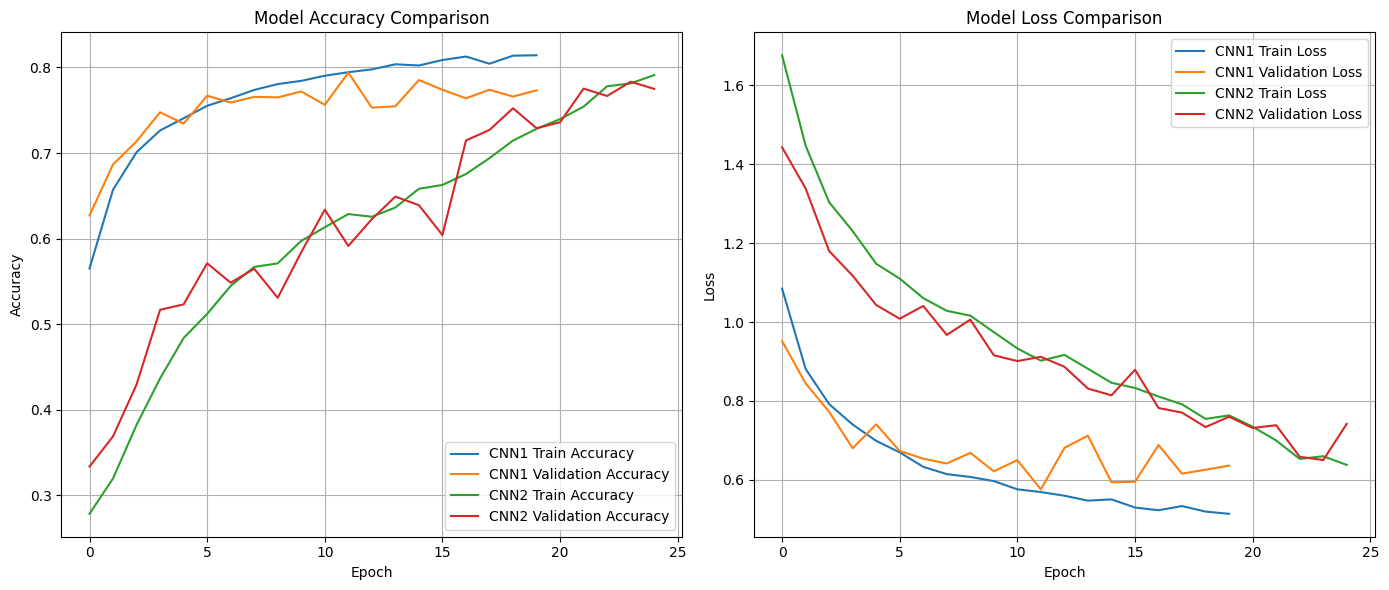


Classification Report for FCNN:
              precision    recall  f1-score   support

           0       0.51      0.41      0.45       437
           1       0.74      0.77      0.75       474
           2       0.64      0.58      0.61       553
           3       0.58      0.66      0.62       525
           4       0.45      0.51      0.48       510
           5       0.68      0.66      0.67       501

    accuracy                           0.60      3000
   macro avg       0.60      0.60      0.60      3000
weighted avg       0.60      0.60      0.60      3000


Classification Report for CNN1:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       437
           1       0.97      0.82      0.89       474
           2       0.75      0.77      0.76       553
           3       0.89      0.59      0.71       525
           4       0.66      0.91      0.77       510
           5       0.74      0.81      0.77       501

    accurac

In [ ]:
print(f"Test Accuracy for FCNN: {fcnn.evaluate(X_test, y_test, verbose=0)[1]:.4f}")
print(f"Test Accuracy for CNN1: {score[1]:.4f}")
print(f"Test Accuracy for CNN2: {score_cnn2[1]:.4f}")


# Plotting accuracy and loss for CNN1 and CNN2
plt.figure(figsize=(14, 6))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(cnn1_history.history['accuracy'], label='CNN1 Train Accuracy')
plt.plot(cnn1_history.history['val_accuracy'], label='CNN1 Validation Accuracy')
plt.plot(cnn2_history.history['accuracy'], label='CNN2 Train Accuracy')
plt.plot(cnn2_history.history['val_accuracy'], label='CNN2 Validation Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(cnn1_history.history['loss'], label='CNN1 Train Loss')
plt.plot(cnn1_history.history['val_loss'], label='CNN1 Validation Loss')
plt.plot(cnn2_history.history['loss'], label='CNN2 Train Loss')
plt.plot(cnn2_history.history['val_loss'], label='CNN2 Validation Loss')
plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


print("\nClassification Report for FCNN:")
print(classification_report(decoded_y_test, decoded_y_pred))

print("\nClassification Report for CNN1:")
print(classification_report(decoded_y_test, decoded_y_pred_cnn1))

print("\nClassification Report for CNN2:")
print(classification_report(decoded_y_test, decoded_y_pred_cnn2))

Para la etiqueta 4, los modelos CNN1 y CNN2 se equivocan más.

229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


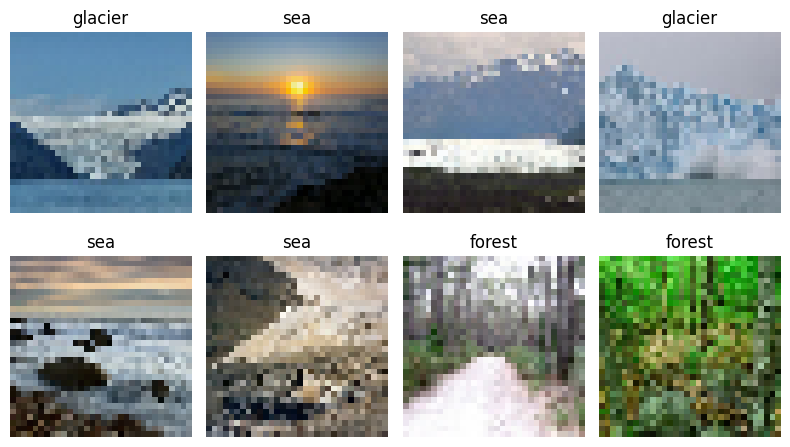

In [ ]:
y_pred_for_X_pred = cnn2.predict(X_pred)
decoded_y_pred_for_X_pred = y_pred_for_X_pred.argmax(axis=1)

# Get class names from the OneHotEncoder
class_names = one_hot.categories_[0]

# Map numerical predictions back to class names
predicted_class_names = [class_names[idx] for idx in decoded_y_pred_for_X_pred]

# Display 8 random images with their predicted labels
show_images(X_pred, predicted_class_names, 8, nrow=2, ncol=4, seed=None)

**CONCLUSION**:

El análisis y la mejora de los modelos de redes neuronales revelan que, para esta tarea de clasificación de imágenes, las Redes Neuronales Convolucionales (CNN) superan significativamente a las Redes Neuronales Completamente Conectadas (FCNN).

Hallazgos Clave:

* El modelo FCNN obtuvo una precisión de prueba de solo 59.97%, lo que sugiere que no es adecuado para capturar las características espaciales de las imágenes.
* Ambos modelos convolucionales, CNN1 y CNN2, mostraron un rendimiento muy superior, con precisiones de prueba de 77.33% y 77.50%, respectivamente. Esto demuestra la eficacia de las CNN en tareas de visión por computadora.
* Aunque el modelo CNN2 fue sometido a una estricta reducción de parámetros (manteniéndolos entre 2.5M y 2.7M), logró una precisión ligeramente superior al CNN1, lo que indica que se encontró un buen equilibrio entre la complejidad del modelo y su capacidad de generalización.
* Los gráficos de entrenamiento y validación confirman tendencias de aprendizaje saludables sin un sobreajuste severo en los modelos convolucionales.